In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import pandas as pd

# Read the data
df = pd.read_csv('FuelConsumption.csv')
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

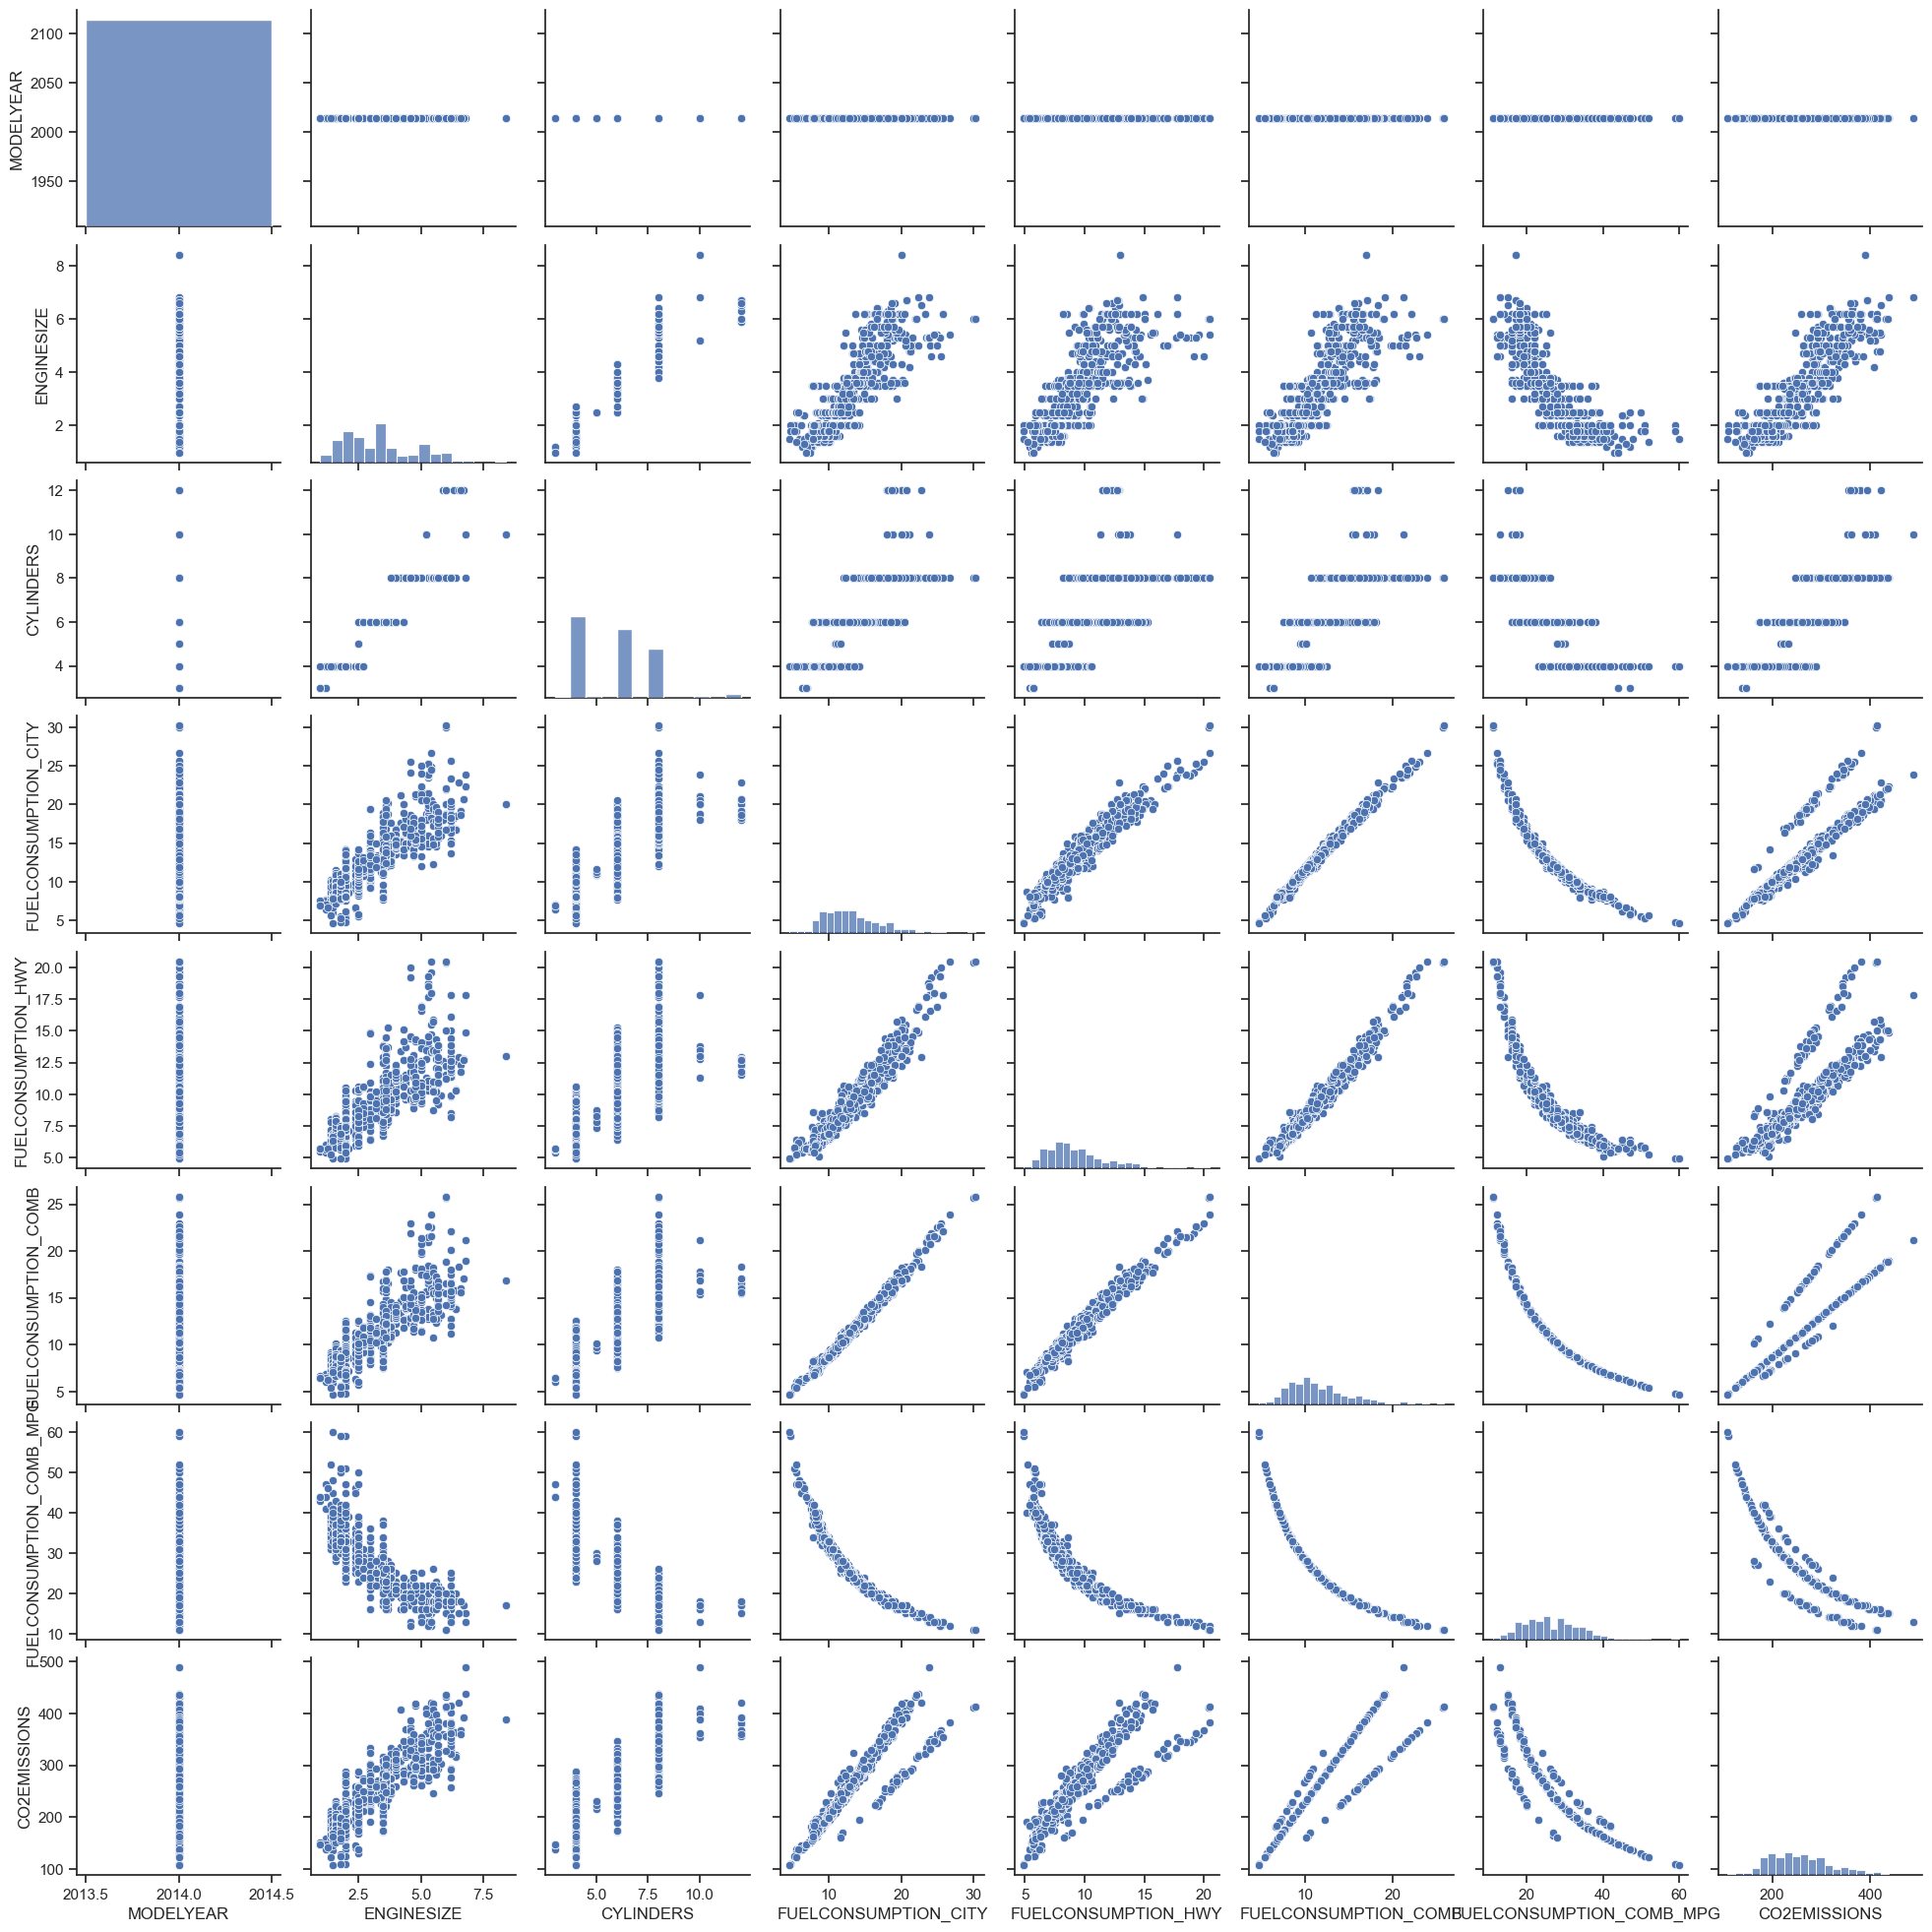

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="ticks", color_codes=True)
sns.pairplot(df)

In [5]:
df.corr(numeric_only=True)['CO2EMISSIONS'].sort_values(ascending=False)

CO2EMISSIONS                1.000000
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
FUELCONSUMPTION_COMB_MPG   -0.906394
MODELYEAR                        NaN
Name: CO2EMISSIONS, dtype: float64

# Simple Linear Regression

In [6]:
X = df[['ENGINESIZE']]
y = df[['CO2EMISSIONS']]

In [7]:
X.isnull().sum()

ENGINESIZE    0
dtype: int64

In [8]:
X.describe()

,ENGINESIZE
count,1067.000000
mean,3.346298
std,1.415895
min,1.000000
25%,2.000000
50%,3.400000
75%,4.300000
max,8.400000


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print('Intercept: ', lin_reg.intercept_)
print('Coefficient: ', lin_reg.coef_)

Intercept:  [126.18920155]
Coefficient:  [[39.24838431]]


In [11]:
y_pred = lin_reg.predict(X_test)

In [12]:
# Plot the regression line

import plotly.express as px

fig = px.scatter(x=X_test['ENGINESIZE'], y=y_test['CO2EMISSIONS'], title='Engine Size vs CO2 Emission',
                  labels={'x':'Engine Size', 'y':'CO2 Emission'}, width=800, height=600)
fig.add_traces(px.line(x=X_test['ENGINESIZE'], y=y_pred.flatten(), color_discrete_sequence=['red']).data)
fig.show()

In [13]:
# Evaluate the model
y_pred = lin_reg.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('R2 score: ', r2_score(y_test, y_pred))  # lin_reg.score(X_test, y_test)
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.7201153918073576
Mean Absolute Error:  25.56889045602356
Mean Squared Error:  1181.528809303555




<img alt="Zero Grad" src="https://i.postimg.cc/cLGvjHYy/machine-learning.png" >


      

# Multiple Linear Regression

In [14]:
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = df[['CO2EMISSIONS']]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [16]:
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train, y_train)

print('Intercept: ', lin_reg2.intercept_)
print('Coefficient: ', lin_reg2.coef_)

Intercept:  [69.05220993]
Coefficient:  [[11.98993058  7.54469599  8.98695981]]


In [17]:
# Evaluate the model
y_pred = lin_reg2.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.8604199405627129
Mean Absolute Error:  18.016270102501476
Mean Squared Error:  589.2351940837906


In [18]:
# Try Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lin_reg3 = LinearRegression()
lin_reg3.fit(X_train, y_train)

y_pred = lin_reg3.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.8604199405627128
Mean Absolute Error:  18.016270102501476
Mean Squared Error:  589.2351940837908


# Polynomial Regression

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_reg = Pipeline([('poly', PolynomialFeatures(degree=2)),
                      ('scaler', StandardScaler()),
                        ('lin_reg', LinearRegression())])

poly_reg.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('scaler', StandardScaler()),
                ('lin_reg', LinearRegression())])

In [20]:
y_pred = poly_reg.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.92266034841026
Mean Absolute Error:  10.217485340766157
Mean Squared Error:  326.48821614328193


In [21]:
# Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {'poly__degree': [2, 3, 4, 5, 6, 7, 8, 9, 10]}
grid_search = GridSearchCV(poly_reg, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

grid_search.best_params_

{'poly__degree': 4}

In [22]:
poly_reg = Pipeline([('poly', PolynomialFeatures(degree=4)),
                      # ('scaler', StandardScaler()),
                        ('lin_reg', LinearRegression())])

poly_reg.fit(X_train, y_train)

y_pred = poly_reg.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.9338457898102885
Mean Absolute Error:  8.313242171469005
Mean Squared Error:  279.26903769594867


# Ridge & Lasso Regression

In [23]:
# Try Ridge Regression
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1)
ridge_reg.fit(X_train, y_train)

y_pred = ridge_reg.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.8603098880967016
Mean Absolute Error:  18.030584466098386
Mean Squared Error:  589.6997789709941


In [24]:
# Try Lasso Regression
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)

y_pred = lasso_reg.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.8602965057459969
Mean Absolute Error:  18.029141984734828
Mean Squared Error:  589.7562723701698


In [25]:
# Try Elastic Net
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_train, y_train)

y_pred = elastic_net.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.8557441304206861
Mean Absolute Error:  18.553567150453983
Mean Squared Error:  608.9740587012969


In [26]:
# Polynomial Regression with Ridge

poly_reg = Pipeline([('poly', PolynomialFeatures(degree=3)),
                    ('scaler', StandardScaler()),
                    ('ridge_reg', Ridge(alpha=1))])

poly_reg.fit(X_train, y_train)

y_pred = poly_reg.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))


R2 score:  0.9276580908834416
Mean Absolute Error:  10.486705888495633
Mean Squared Error:  305.3903188645589


In [27]:
# Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {'poly__degree': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                'ridge_reg__alpha': [0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(poly_reg, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

grid_search.best_params_

{'poly__degree': 4, 'ridge_reg__alpha': 1}

In [28]:
poly_reg = Pipeline([('poly', PolynomialFeatures(degree=4)),
                    ('scaler', StandardScaler()),
                    ('ridge_reg', Ridge(alpha=1))])

poly_reg.fit(X_train, y_train)

y_pred = poly_reg.predict(X_test)

print('R2 score: ', r2_score(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))

R2 score:  0.9344603465477626
Mean Absolute Error:  8.5101218318813
Mean Squared Error:  276.67469535263086
